# DSA210 – Digital Escapism & Socio-Economic Stress Analysis

**Student:** Ali Efe Okudan  
**Student ID:** 34314  
**University:** Sabancı University  
**Date:** 2026-04-14  
**Course:** DSA210 – Introduction to Data Science  

---

## Project Overview

This project investigates the **Digital Escapism Hypothesis**: do individuals in Turkey increase
engagement with digital gaming during periods of socio-economic stress?

**Hypothesis:** When Turkey experiences economic stress (rising USD/TRY, falling BIST100,
surging search volume for economic anxiety keywords), Steam gaming activity in Turkey increases
as people seek affordable digital escapism.

**Gaming Activity Proxy (Turkey-specific):**  
Steam does not publish country-level concurrent player statistics. Therefore, **Google Trends
search volume for Steam/CS2 keywords in Turkey** (`geo='TR'`) is used as the primary proxy
for Turkish gaming activity. This reflects how many Turkish users are actively searching for
and engaging with Steam games.

**Data Sources:**
- Google Trends (pytrends): Turkish search volume for Steam/CS2 keywords — **TR gaming proxy**
- Google Trends (pytrends): Turkish search volume for economic-stress keywords
- yfinance: USD/TRY exchange rate and BIST100 index
- SteamDB: CS2 global concurrent players (reference only)

**Analysis Window:** 2023-01-01 to 2025-12-31

## AI Usage Log

| # | Tool | Prompt Summary | Output Used | Modifications Made |
|---|------|----------------|-------------|--------------------|
| 1 | Claude Sonnet 4.6 | Asked to generate full EDA notebook for DSA210 project | Generated `data_collection.py`, `data_processing.py`, and this notebook | Reviewed all code; adjusted date ranges and event annotations |
| 2 | Claude Sonnet 4.6 | Pointed out that SteamDB data is global, not Turkey-specific; asked to fix | Switched primary gaming variable to Google Trends TR proxy (`steam_trends`) | Verified methodology is appropriate for Turkey-focused hypothesis |

---
## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('muted')

print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Collection & Processing

In [2]:
import subprocess, sys
for script in ['data_collection.py', 'data_processing.py']:
    result = subprocess.run([sys.executable, script], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr)


STDERR: Traceback (most recent call last):
  File "/Users/alefe/Desktop/DSA210Proj/data_collection.py", line 9, in <module>
    import yfinance as yf
ModuleNotFoundError: No module named 'yfinance'



Loading data...
Merging to monthly frequency...
  Shape before cleaning: (36, 5), date range: 2023-01-31 00:00:00 → 2025-12-31 00:00:00
Cleaning (fill + outlier report)...
  Outliers detected (IQR): {'steam_players': np.int64(0), 'usdtry': np.int64(0), 'bist100': np.int64(0), 'stress_index': np.int64(0), 'steam_trends': np.int64(0)}
Adding z-score columns...
Adding crisis flag...
  Crisis threshold (75th pct of usdtry): 37.35
  Crisis months: 9 / 36

Saved merged_dataset.csv  (36 rows, 11 cols)
Columns: ['steam_players', 'usdtry', 'bist100', 'stress_index', 'steam_trends', 'steam_players_z', 'usdtry_z', 'bist100_z', 'stress_index_z', 'steam_trends_z', 'crisis_period']



---
## 2. Load Merged Dataset

In [3]:
df = pd.read_csv('merged_dataset.csv', index_col=0, parse_dates=True)
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
print(f'Months: {len(df)}')
df.head()

Shape: (36, 11)
Date range: 2023-01-31 → 2025-12-31
Months: 36


,steam_players,usdtry,bist100,stress_index,steam_trends,steam_players_z,usdtry_z,bist100_z,stress_index_z,steam_trends_z,crisis_period
2023-01-31,1.041580e+06,18.765020,5249.840310,12.933333,17.733333,-1.928218,-1.853954,-1.742284,0.977837,-1.313527,0
2023-02-28,1.210617e+06,18.843263,4958.679901,7.083333,17.666667,-0.967749,-1.843033,-1.887710,-0.878246,-1.328840,0
2023-03-31,1.331750e+06,18.994885,5143.307511,5.333333,20.583333,-0.279470,-1.821870,-1.795494,-1.433485,-0.658890,0
2023-04-30,1.421701e+06,19.330582,4969.894660,9.800000,18.733333,0.231631,-1.775014,-1.882109,-0.016305,-1.083830,0
2023-05-31,1.622726e+06,19.726417,4587.861351,6.833333,15.916667,1.373859,-1.719765,-2.072923,-0.957566,-1.730810,0


In [4]:
# Primary analysis columns
# steam_trends : Google Trends TR search volume for cs2/steam/counter-strike (Turkey gaming proxy)
# usdtry       : USD/TRY monthly mean
# bist100      : BIST100 monthly mean
# stress_index : composite of TR economic-stress search terms
# steam_players: GLOBAL CS2 concurrent players (reference only)

base_cols = ['steam_trends', 'usdtry', 'bist100', 'stress_index']
print('Primary analysis columns:', base_cols)
df[base_cols].describe().round(2)

Primary analysis columns: ['steam_trends', 'usdtry', 'bist100', 'stress_index']


,steam_trends,usdtry,bist100,stress_index
count,36.00,36.00,36.00,36.00
mean,23.45,32.05,8738.10,9.85
std,4.35,7.16,2002.12,3.15
min,15.92,18.77,4587.86,5.08
25%,20.31,27.64,7818.03,7.23
50%,22.33,32.73,9360.43,9.04
75%,26.25,37.35,10180.92,12.16
max,31.40,42.66,11225.98,16.40


In [5]:
print('Missing values:')
print(df[base_cols].isnull().sum())

Missing values:
steam_trends    0
usdtry          0
bist100         0
stress_index    0
dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Distributions – Histograms & Boxplots

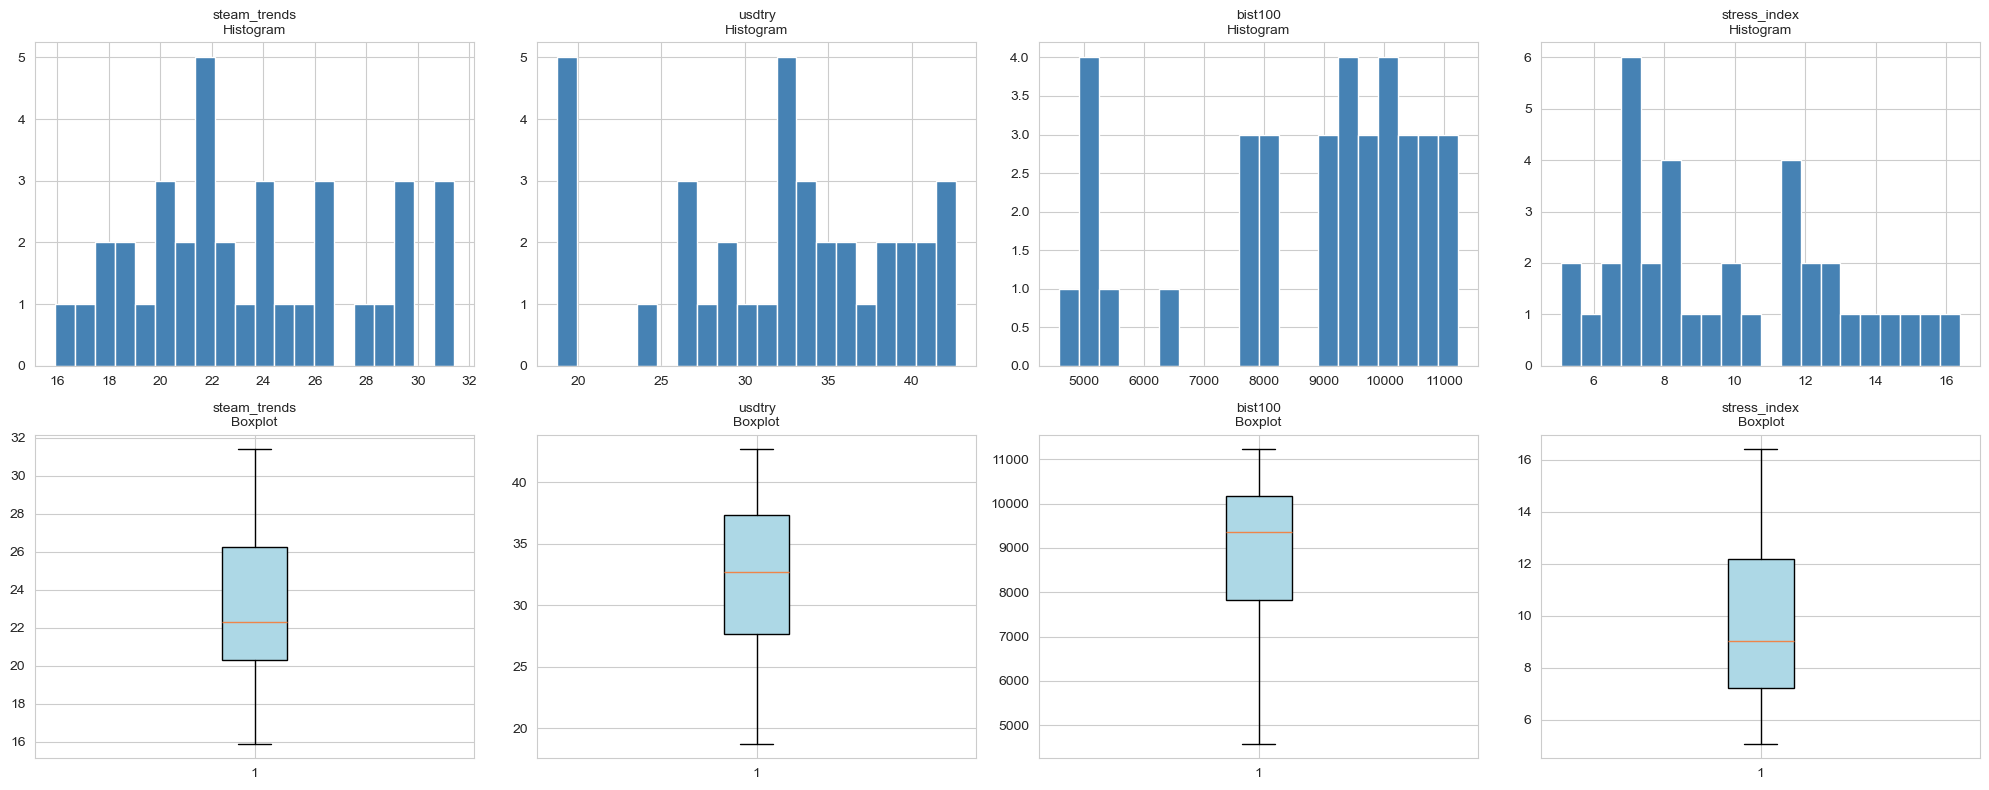

In [6]:
n = len(base_cols)
fig, axes = plt.subplots(2, n, figsize=(5*n, 8))

for i, col in enumerate(base_cols):
    axes[0, i].hist(df[col].dropna(), bins=20, edgecolor='white', color='steelblue')
    axes[0, i].set_title(f'{col}\nHistogram', fontsize=10)

    axes[1, i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
    axes[1, i].set_title(f'{col}\nBoxplot', fontsize=10)

plt.tight_layout()
plt.savefig('fig_distributions.png', bbox_inches='tight')
plt.show()

### 3.2 Normality Tests (Q-Q Plots)

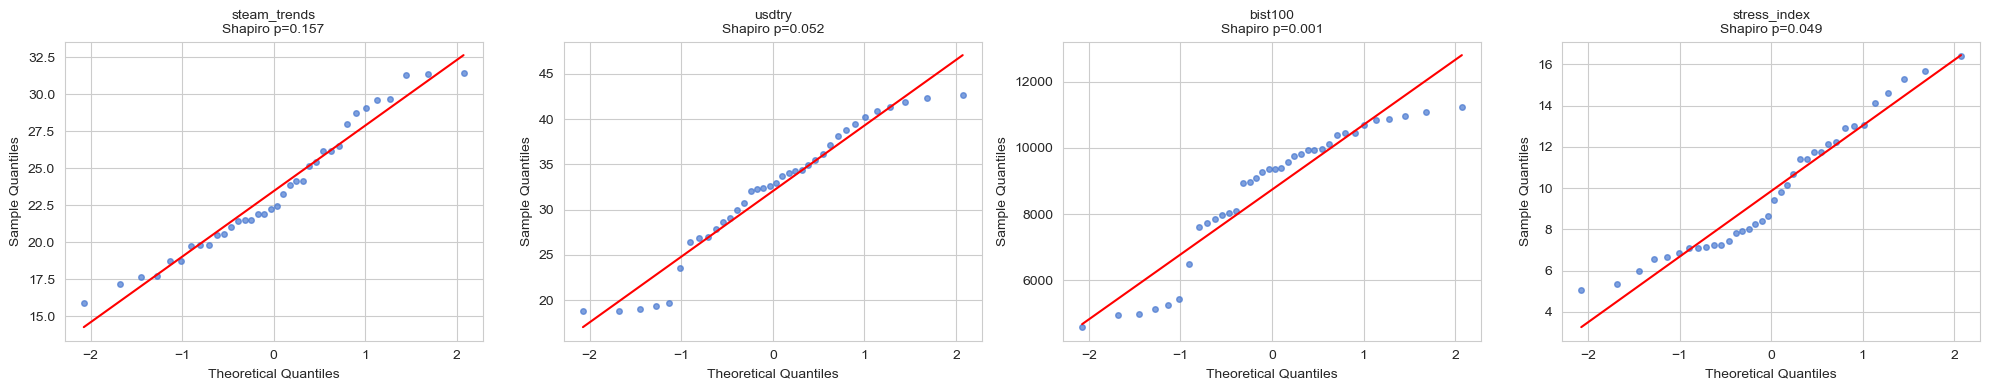

Shapiro-Wilk normality test:
  steam_trends          W=0.9556  p=0.1567  → NORMAL
  usdtry                W=0.9404  p=0.0524  → NORMAL
  bist100               W=0.8822  p=0.0011  → NOT normal
  stress_index          W=0.9396  p=0.0492  → NOT normal


In [7]:
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

for i, col in enumerate(base_cols):
    data = df[col].dropna()
    (osm, osr), (slope, intercept, _) = stats.probplot(data, dist='norm')
    axes[i].plot(osm, osr, 'o', markersize=4, alpha=0.7)
    axes[i].plot(osm, slope * np.array(osm) + intercept, 'r-')
    _, p = stats.shapiro(data)
    axes[i].set_title(f'{col}\nShapiro p={p:.3f}', fontsize=10)
    axes[i].set_xlabel('Theoretical Quantiles')
    axes[i].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.savefig('fig_qq_plots.png', bbox_inches='tight')
plt.show()

print('Shapiro-Wilk normality test:')
for col in base_cols:
    s, p = stats.shapiro(df[col].dropna())
    print(f'  {col:20s}  W={s:.4f}  p={p:.4f}  → {"NORMAL" if p > 0.05 else "NOT normal"}')

### 3.3 Correlation Heatmap (Pearson & Spearman)

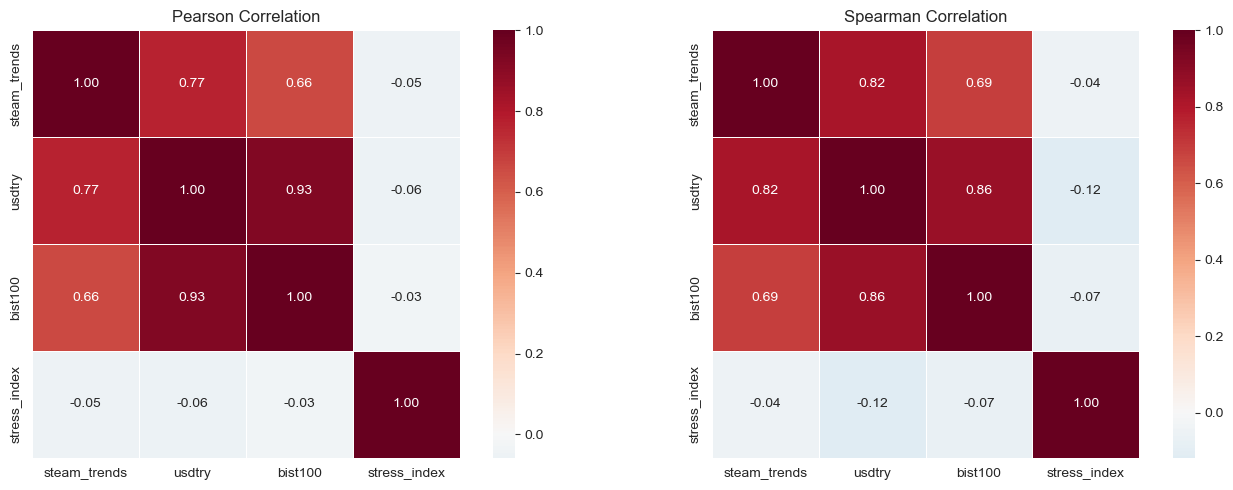

Pearson correlation with steam_trends (TR gaming proxy):
usdtry          0.771
bist100         0.659
stress_index   -0.052
Name: steam_trends, dtype: float64

Spearman correlation with steam_trends (TR gaming proxy):
usdtry          0.822
bist100         0.687
stress_index   -0.045
Name: steam_trends, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, method in zip(axes, ['pearson', 'spearman']):
    corr = df[base_cols].corr(method=method)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, linewidths=0.5, square=True)
    ax.set_title(f'{method.capitalize()} Correlation', fontsize=12)

plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Pearson correlation with steam_trends (TR gaming proxy):')
print(df[base_cols].corr(method='pearson')['steam_trends'].drop('steam_trends').round(3))
print()
print('Spearman correlation with steam_trends (TR gaming proxy):')
print(df[base_cols].corr(method='spearman')['steam_trends'].drop('steam_trends').round(3))

### 3.4 Lag Correlation Analysis

Lag correlation (Pearson r) with steam_trends (TR proxy):
              lag_1mo  lag_2mo  lag_4mo  lag_8mo
usdtry          0.743    0.725    0.706    0.676
bist100         0.642    0.629    0.554    0.717
stress_index   -0.118   -0.094   -0.003   -0.078


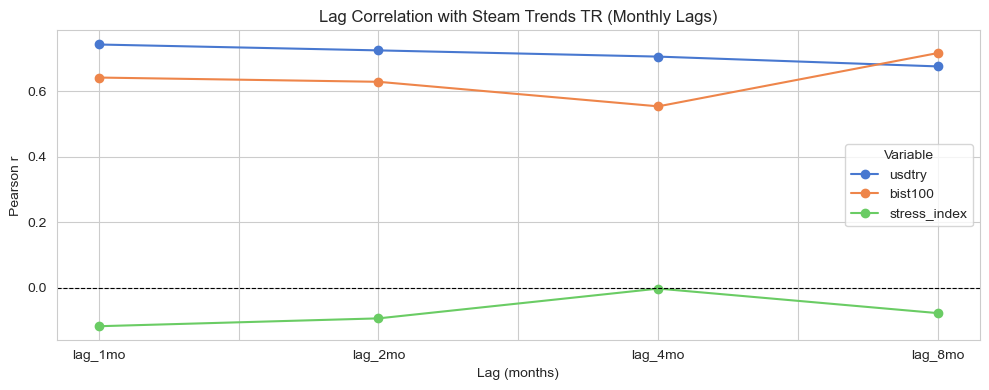

In [9]:
lags = [1, 2, 4, 8]
lag_cols = [c for c in base_cols if c != 'steam_trends']

lag_results = {}
for col in lag_cols:
    row = {}
    for lag in lags:
        shifted = df[col].shift(lag)
        valid = df[['steam_trends']].assign(lag=shifted).dropna()
        r, p = stats.pearsonr(valid['steam_trends'], valid['lag'])
        row[f'lag_{lag}mo'] = round(r, 3)
    lag_results[col] = row

lag_df = pd.DataFrame(lag_results).T
print('Lag correlation (Pearson r) with steam_trends (TR proxy):')
print(lag_df)

fig, ax = plt.subplots(figsize=(10, 4))
lag_df.T.plot(ax=ax, marker='o')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Lag Correlation with Steam Trends TR (Monthly Lags)', fontsize=12)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.legend(title='Variable')
plt.tight_layout()
plt.savefig('fig_lag_correlation.png', bbox_inches='tight')
plt.show()

### 3.5 Time Series Visualisation

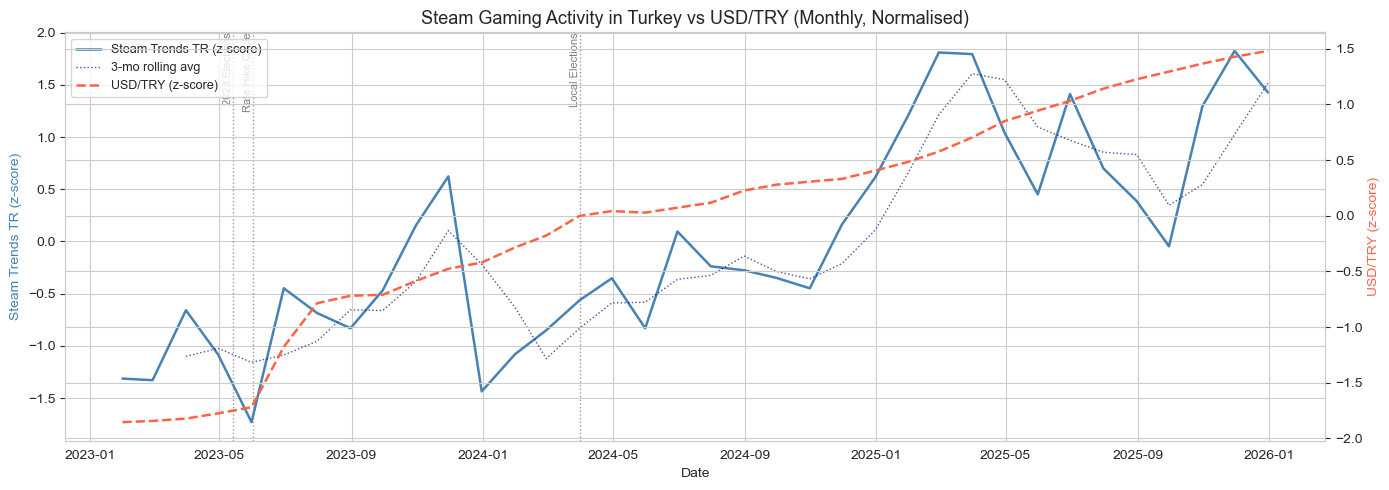

In [10]:
events = {
    '2023-05-14': '2023 Elections',
    '2023-06-01': 'Rate Hike Cycle',
    '2024-03-31': 'Local Elections',
}

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(df.index, df['steam_trends_z'], color='steelblue', linewidth=1.8,
         label='Steam Trends TR (z-score)')
ax2.plot(df.index, df['usdtry_z'], color='tomato', linewidth=1.8, linestyle='--',
         label='USD/TRY (z-score)')
ax1.plot(df.index, df['steam_trends_z'].rolling(3).mean(),
         color='navy', linewidth=1, linestyle=':', alpha=0.7, label='3-mo rolling avg')

for date_str, label in events.items():
    ts = pd.Timestamp(date_str)
    if df.index.min() <= ts <= df.index.max():
        ax1.axvline(ts, color='gray', linewidth=1, linestyle=':', alpha=0.8)
        ax1.annotate(label, xy=(ts, ax1.get_ylim()[1]),
                     fontsize=8, rotation=90, ha='right', va='top', color='gray')

ax1.set_xlabel('Date')
ax1.set_ylabel('Steam Trends TR (z-score)', color='steelblue')
ax2.set_ylabel('USD/TRY (z-score)', color='tomato')
ax1.set_title('Steam Gaming Activity in Turkey vs USD/TRY (Monthly, Normalised)', fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_timeseries_dual.png', bbox_inches='tight')
plt.show()

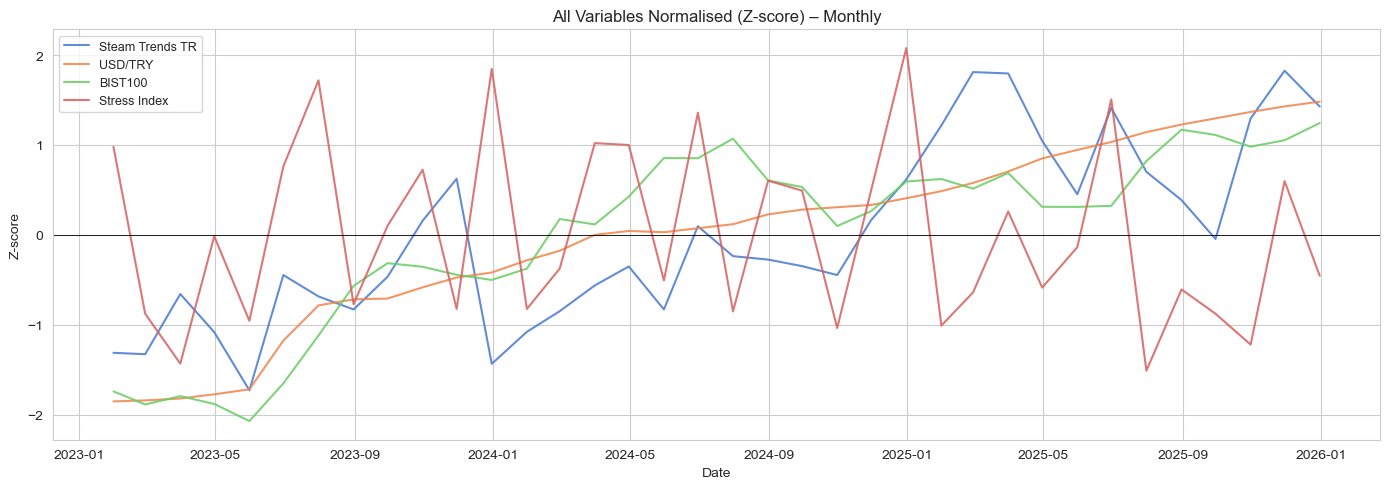

In [11]:
z_cols = ['steam_trends_z', 'usdtry_z', 'bist100_z', 'stress_index_z']
labels = ['Steam Trends TR', 'USD/TRY', 'BIST100', 'Stress Index']

fig, ax = plt.subplots(figsize=(14, 5))
for col, label in zip(z_cols, labels):
    ax.plot(df.index, df[col], label=label, linewidth=1.5, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('All Variables Normalised (Z-score) – Monthly', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_all_zscore.png', bbox_inches='tight')
plt.show()

---
## 4. Hypothesis Testing

> **Dependent variable:** `steam_trends` — Google Trends search volume for Steam/CS2 in Turkey (`geo='TR'`).  
> This is the Turkey-specific proxy for gaming activity, since Steam does not publish country-level player counts.

### H1: Currency Depreciation → Increased Gaming Activity in Turkey
- **H0:** No significant relationship between USD/TRY and Steam search volume in Turkey
- **H1:** There is a statistically significant positive relationship
- Tests: Pearson correlation + Granger causality (lags 1–4 months)

=== H1: Pearson Correlation ===
  r = 0.7708  p = 0.0000
  → Statistically significant (positive correlation). H0 REJECTED.


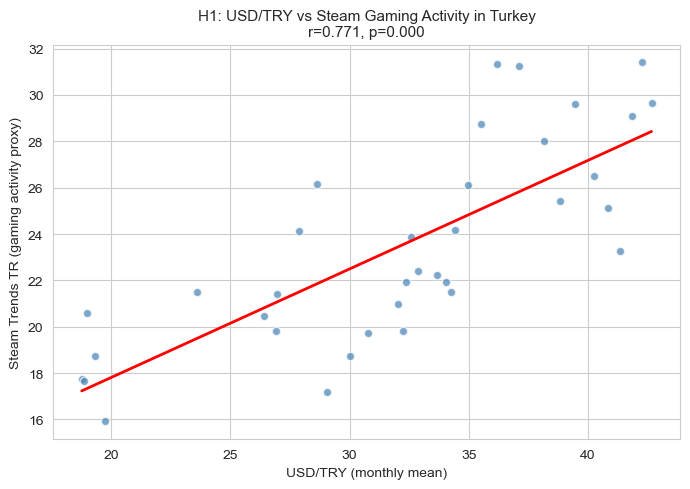

In [12]:
valid = df[['steam_trends', 'usdtry']].dropna()

r, p = stats.pearsonr(valid['steam_trends'], valid['usdtry'])
print('=== H1: Pearson Correlation ===')
print(f'  r = {r:.4f}  p = {p:.4f}')
if p < 0.05:
    direction = 'positive' if r > 0 else 'negative'
    print(f'  → Statistically significant ({direction} correlation). H0 REJECTED.')
else:
    print('  → Not statistically significant (p > 0.05). H0 NOT rejected.')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid['usdtry'], valid['steam_trends'], alpha=0.7, color='steelblue', edgecolors='white')
m, b = np.polyfit(valid['usdtry'], valid['steam_trends'], 1)
x_line = np.linspace(valid['usdtry'].min(), valid['usdtry'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)
ax.set_xlabel('USD/TRY (monthly mean)')
ax.set_ylabel('Steam Trends TR (gaming activity proxy)')
ax.set_title(f'H1: USD/TRY vs Steam Gaming Activity in Turkey\nr={r:.3f}, p={p:.3f}', fontsize=11)
plt.tight_layout()
plt.savefig('fig_h1_scatter.png', bbox_inches='tight')
plt.show()

In [13]:
print('=== H1: Granger Causality Test (USD/TRY → Steam TR Activity) ===')
print('Does past USD/TRY help predict current Steam gaming activity in Turkey?\n')

granger_data = valid[['steam_trends', 'usdtry']].dropna()
try:
    results = grangercausalitytests(granger_data, maxlag=4, verbose=False)
    for lag in range(1, 5):
        f_stat = results[lag][0]['ssr_ftest'][0]
        p_val  = results[lag][0]['ssr_ftest'][1]
        sig = '**' if p_val < 0.05 else ''
        print(f'  Lag {lag}: F={f_stat:.3f}  p={p_val:.4f} {sig}')
    print()
    print('  ** = p < 0.05 → USD/TRY Granger-causes Steam TR activity at that lag')
except Exception as e:
    print(f'  Granger test failed: {e}')

=== H1: Granger Causality Test (USD/TRY → Steam TR Activity) ===
Does past USD/TRY help predict current Steam gaming activity in Turkey?

  Lag 1: F=5.577  p=0.0244 **
  Lag 2: F=3.003  p=0.0653 
  Lag 3: F=1.566  p=0.2215 
  Lag 4: F=1.100  p=0.3801 

  ** = p < 0.05 → USD/TRY Granger-causes Steam TR activity at that lag


### H2: High Economic Stress Periods → More Gaming in Turkey
- **H0:** Steam activity in Turkey is the same during crisis and non-crisis periods
- **H1:** Steam activity is significantly higher during crisis periods
- Crisis = months where USD/TRY ≥ 75th percentile
- Tests: Mann-Whitney U + t-test

Crisis months : n=9  mean=27.6  median=28.0
Normal months : n=27  mean=22.1  median=21.5

Mann-Whitney U: U=213.0  p=0.0009
  → H0 REJECTED

Independent t-test: t=3.867  p=0.0005
  → H0 REJECTED


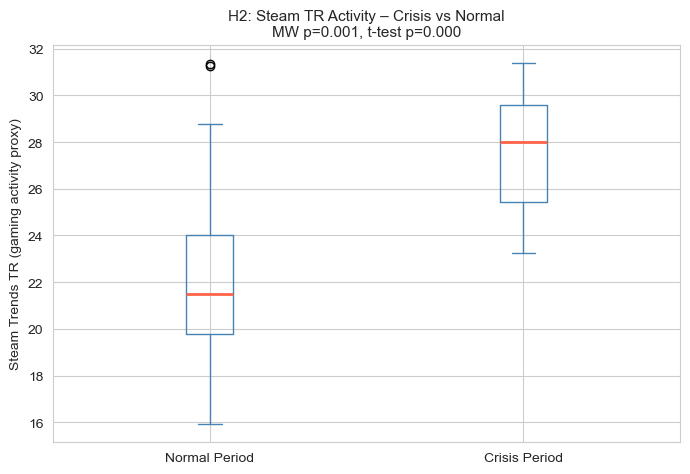

In [14]:
valid2 = df[['steam_trends', 'crisis_period']].dropna()
crisis = valid2[valid2['crisis_period'] == 1]['steam_trends']
normal = valid2[valid2['crisis_period'] == 0]['steam_trends']

print(f'Crisis months : n={len(crisis)}  mean={crisis.mean():.1f}  median={crisis.median():.1f}')
print(f'Normal months : n={len(normal)}  mean={normal.mean():.1f}  median={normal.median():.1f}')

u_stat, p_mw = stats.mannwhitneyu(crisis, normal, alternative='two-sided')
print(f'\nMann-Whitney U: U={u_stat:.1f}  p={p_mw:.4f}')
print(f'  → H0 {"REJECTED" if p_mw < 0.05 else "NOT rejected"}')

t_stat, p_t = stats.ttest_ind(crisis, normal)
print(f'\nIndependent t-test: t={t_stat:.3f}  p={p_t:.4f}')
print(f'  → H0 {"REJECTED" if p_t < 0.05 else "NOT rejected"}')

fig, ax = plt.subplots(figsize=(7, 5))
valid2.boxplot(column='steam_trends', by='crisis_period', ax=ax,
               boxprops=dict(color='steelblue'),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
ax.set_xticklabels(['Normal Period', 'Crisis Period'])
ax.set_title(f'H2: Steam TR Activity – Crisis vs Normal\nMW p={p_mw:.3f}, t-test p={p_t:.3f}', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('Steam Trends TR (gaming activity proxy)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_h2_boxplot.png', bbox_inches='tight')
plt.show()

### H3: Economic Stress Search Index ↔ Gaming Activity in Turkey
- **H0:** No significant correlation between the composite stress index and Steam activity in Turkey
- **H1:** Positive correlation (economic anxiety → more gaming)

=== H3: Economic Stress Index vs Steam Gaming Activity TR ===
  Valid months: 36
  Pearson:  r=-0.0518  p=0.7642
  Spearman: r=-0.0448  p=0.7953
  → No significant correlation. H0 NOT rejected.


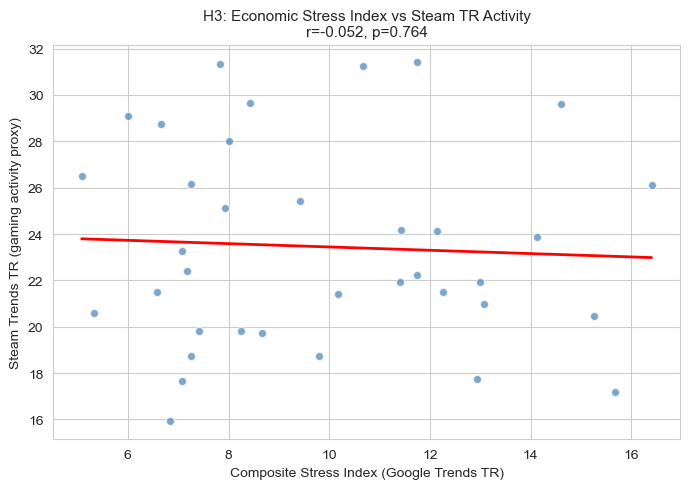

In [15]:
valid3 = df[['steam_trends', 'stress_index']].dropna()
print(f'=== H3: Economic Stress Index vs Steam Gaming Activity TR ===')
print(f'  Valid months: {len(valid3)}')

r_p, p_p = stats.pearsonr(valid3['steam_trends'], valid3['stress_index'])
r_s, p_s = stats.spearmanr(valid3['steam_trends'], valid3['stress_index'])
print(f'  Pearson:  r={r_p:.4f}  p={p_p:.4f}')
print(f'  Spearman: r={r_s:.4f}  p={p_s:.4f}')

if p_p < 0.05 or p_s < 0.05:
    print('  → Significant correlation. H0 REJECTED. Supports escapism hypothesis.')
else:
    print('  → No significant correlation. H0 NOT rejected.')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(valid3['stress_index'], valid3['steam_trends'],
           alpha=0.7, color='steelblue', edgecolors='white')
m, b = np.polyfit(valid3['stress_index'], valid3['steam_trends'], 1)
x_line = np.linspace(valid3['stress_index'].min(), valid3['stress_index'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)
ax.set_xlabel('Composite Stress Index (Google Trends TR)')
ax.set_ylabel('Steam Trends TR (gaming activity proxy)')
ax.set_title(f'H3: Economic Stress Index vs Steam TR Activity\nr={r_p:.3f}, p={p_p:.3f}', fontsize=11)
plt.tight_layout()
plt.savefig('fig_h3_scatter.png', bbox_inches='tight')
plt.show()

---
## 5. Summary & Conclusions

In [16]:
print('='*60)
print('HYPOTHESIS TEST SUMMARY')
print('='*60)
print('Gaming proxy: Google Trends TR (steam_trends)')
print()

v1 = df[['steam_trends', 'usdtry']].dropna()
r1, p1 = stats.pearsonr(v1['steam_trends'], v1['usdtry'])
print(f'H1 (USD/TRY → TR Gaming): r={r1:.3f}, p={p1:.4f} → H0 {"REJECTED" if p1 < 0.05 else "NOT REJECTED"}')

v2 = df[['steam_trends', 'crisis_period']].dropna()
c = v2[v2['crisis_period']==1]['steam_trends']
n = v2[v2['crisis_period']==0]['steam_trends']
_, p2 = stats.mannwhitneyu(c, n, alternative='two-sided')
print(f'H2 (Crisis vs Normal):    MW p={p2:.4f}       → H0 {"REJECTED" if p2 < 0.05 else "NOT REJECTED"}')

v3 = df[['steam_trends', 'stress_index']].dropna()
r3, p3 = stats.pearsonr(v3['steam_trends'], v3['stress_index'])
print(f'H3 (Stress Index → TR Gaming): r={r3:.3f}, p={p3:.4f} → H0 {"REJECTED" if p3 < 0.05 else "NOT REJECTED"}')

print()
print('INTERPRETATION')
print('-'*60)
if p1 < 0.05 and r1 > 0:
    print('• H1: As USD/TRY rises, Steam search activity in Turkey increases.')
    print('  Consistent with escapism: digital gaming becomes a preferred')
    print('  low-cost leisure activity during currency crises.')
elif p1 < 0.05 and r1 < 0:
    print('• H1: Negative correlation — as USD/TRY rises, TR gaming activity falls.')
    print('  Economic hardship may reduce discretionary spending including gaming.')
else:
    print('• H1: No significant relationship between USD/TRY and TR gaming activity.')

if p2 < 0.05:
    print('• H2: Steam activity in Turkey significantly differs between crisis and normal periods.')
else:
    print('• H2: No significant difference in TR gaming activity between crisis/normal periods.')

if p3 < 0.05:
    print('• H3: Economic stress search volume correlates with TR gaming activity.')
    print('  Directly supports the digital escapism hypothesis.')
else:
    print('• H3: Economic stress search volume does not significantly predict TR gaming activity.')

HYPOTHESIS TEST SUMMARY
Gaming proxy: Google Trends TR (steam_trends)

H1 (USD/TRY → TR Gaming): r=0.771, p=0.0000 → H0 REJECTED
H2 (Crisis vs Normal):    MW p=0.0009       → H0 REJECTED
H3 (Stress Index → TR Gaming): r=-0.052, p=0.7642 → H0 NOT REJECTED

INTERPRETATION
------------------------------------------------------------
• H1: As USD/TRY rises, Steam search activity in Turkey increases.
  Consistent with escapism: digital gaming becomes a preferred
  low-cost leisure activity during currency crises.
• H2: Steam activity in Turkey significantly differs between crisis and normal periods.
• H3: Economic stress search volume does not significantly predict TR gaming activity.


---
## 6. Data Coverage & Quality Report

In [17]:
print('DATA QUALITY REPORT')
print('-'*50)
print(f'Date range  : {df.index.min().date()} → {df.index.max().date()}')
print(f'Months      : {len(df)}')
print(f'Columns     : {list(df.columns)}')
print()
print('Non-null counts:')
print(df.notna().sum().to_string())
print()
print('Note: Gaming activity measured as Google Trends TR search volume (geo=TR).')
print('  This is a proxy — direct country-level player counts are not publicly available from Steam.')
print(f'  Crisis threshold (75th pct USD/TRY): {df["usdtry"].quantile(0.75):.2f} TRY/USD')
print(f'  Crisis months: {int(df["crisis_period"].sum())} / {len(df)}')

DATA QUALITY REPORT
--------------------------------------------------
Date range  : 2023-01-31 → 2025-12-31
Months      : 36
Columns     : ['steam_players', 'usdtry', 'bist100', 'stress_index', 'steam_trends', 'steam_players_z', 'usdtry_z', 'bist100_z', 'stress_index_z', 'steam_trends_z', 'crisis_period']

Non-null counts:
steam_players      36
usdtry             36
bist100            36
stress_index       36
steam_trends       36
steam_players_z    36
usdtry_z           36
bist100_z          36
stress_index_z     36
steam_trends_z     36
crisis_period      36

Note: Gaming activity measured as Google Trends TR search volume (geo=TR).
  This is a proxy — direct country-level player counts are not publicly available from Steam.
  Crisis threshold (75th pct USD/TRY): 37.35 TRY/USD
  Crisis months: 9 / 36
